# VAE on MNIST 

Loss = reconstruction (BCE) + KL divergence.


In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

torch.manual_seed(0)
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
device


device(type='mps')

## Data

In [2]:
batch_size = 128
train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=True)
x, _ = next(iter(train_loader))
x.shape, x.min().item(), x.max().item()


(torch.Size([128, 1, 28, 28]), 0.0, 1.0)

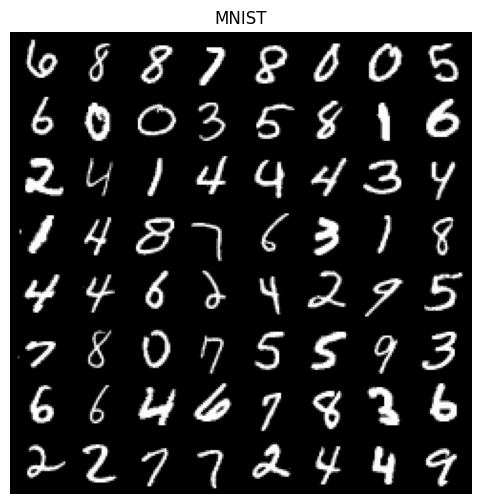

In [3]:
def show_batch(x, n=64, title=""):
    x = x[:n].detach().cpu()
    grid = make_grid(x, nrow=int(math.sqrt(n)))
    plt.figure(figsize=(6,6))
    plt.title(title)
    plt.axis("off")
    plt.imshow(grid.permute(1,2,0).squeeze(), cmap="gray")
    plt.show()

show_batch(x, title="MNIST")


## Model

In [4]:
class VAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.latent_dim = latent_dim
        self.enc = nn.Sequential(nn.Flatten(), nn.Linear(28*28, 400), nn.ReLU(True))
        self.mu = nn.Linear(400, latent_dim)
        self.logvar = nn.Linear(400, latent_dim)
        self.dec = nn.Sequential(nn.Linear(latent_dim, 400), nn.ReLU(True), nn.Linear(400, 28*28), nn.Sigmoid())

    def encode(self, x):
        h = self.enc(x)
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        xhat = self.dec(z)
        return xhat.view(-1, 1, 28, 28)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

vae = VAE(latent_dim=16).to(device)
sum(p.numel() for p in vae.parameters())


648016

## Loss

In [5]:
def kl_divergence(mu, logvar):
    return -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)

def loss_fn(x, xhat, mu, logvar):
    recon = F.binary_cross_entropy(xhat, x, reduction="none").view(x.size(0), -1).sum(dim=1)
    kl = kl_divergence(mu, logvar)
    return (recon + kl).mean(), recon.mean(), kl.mean()


## Train

Epoch 1/5:   0%|          | 0/468 [00:00<?, ?it/s]

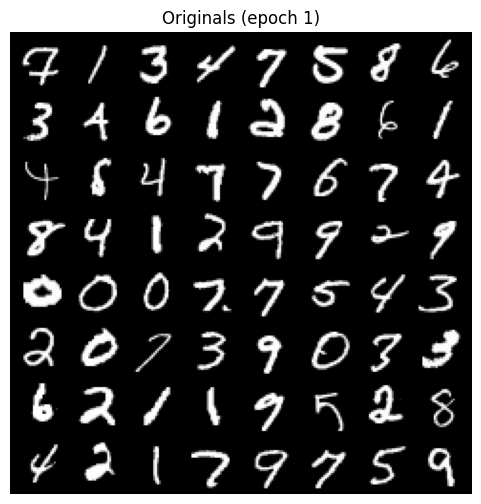

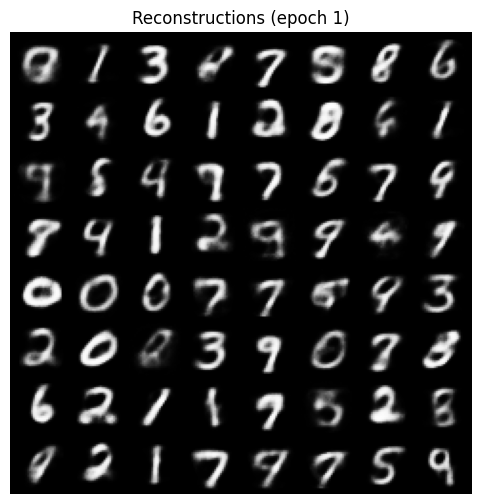

Epoch 2/5:   0%|          | 0/468 [00:00<?, ?it/s]

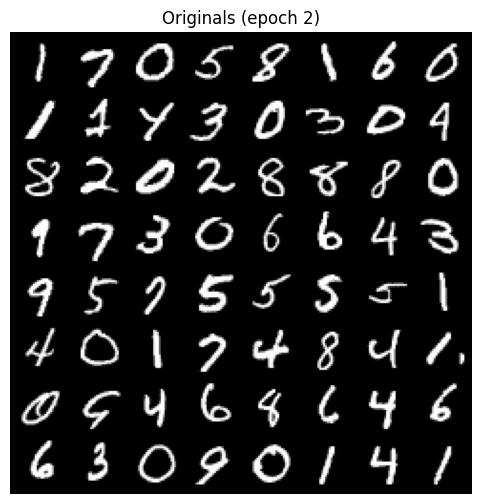

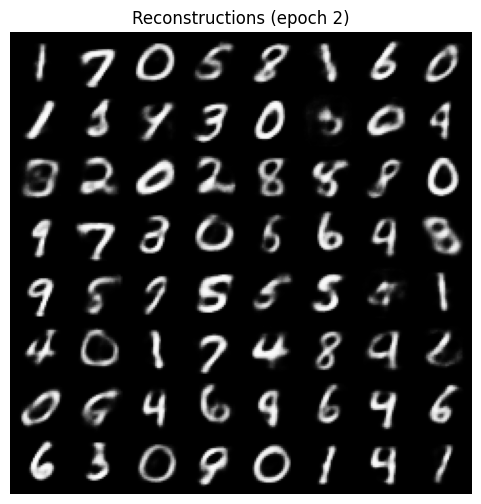

Epoch 3/5:   0%|          | 0/468 [00:00<?, ?it/s]

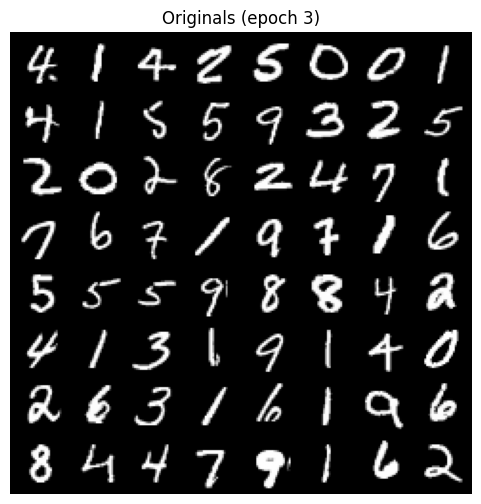

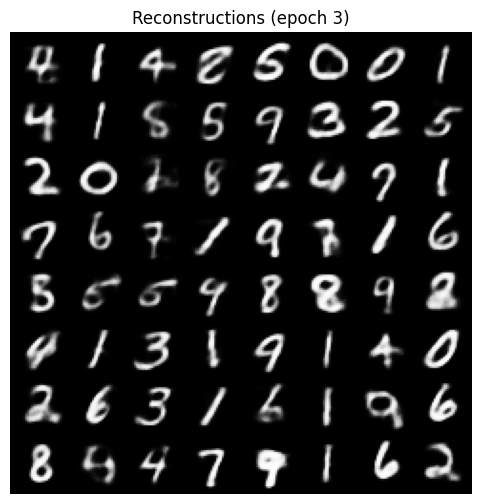

Epoch 4/5:   0%|          | 0/468 [00:00<?, ?it/s]

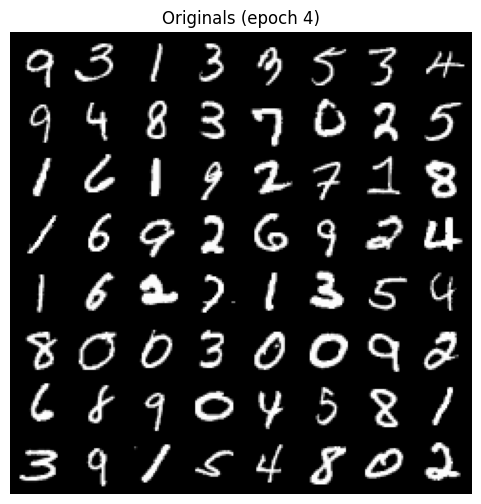

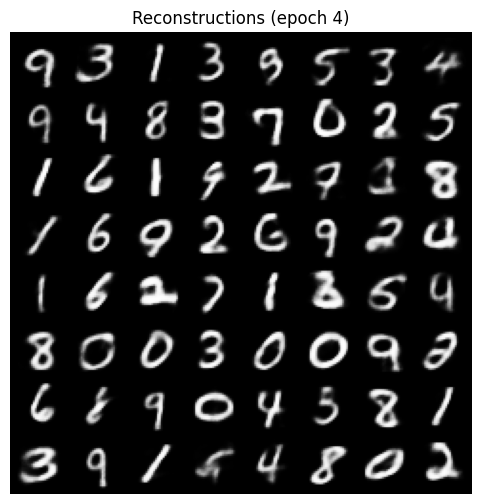

Epoch 5/5:   0%|          | 0/468 [00:00<?, ?it/s]

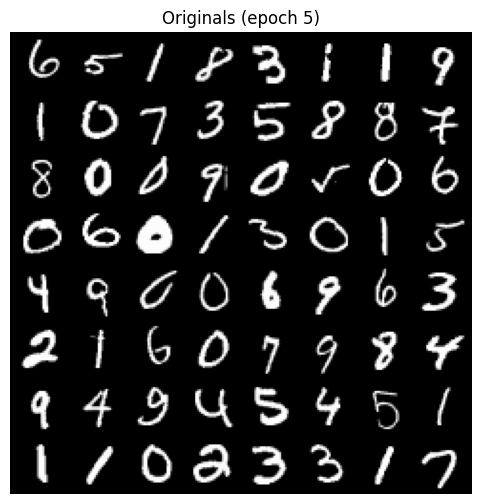

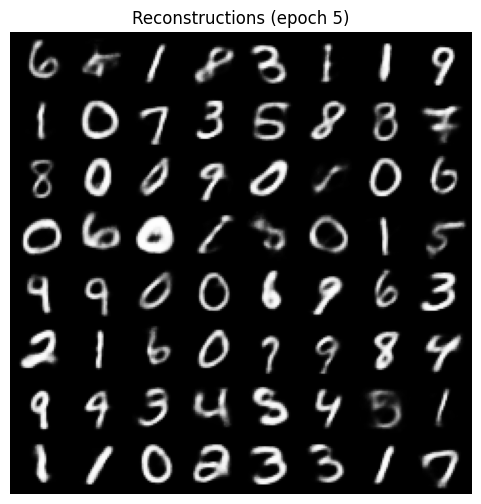

In [6]:
opt = torch.optim.Adam(vae.parameters(), lr=1e-3)
epochs = 5

vae.train()
for epoch in range(epochs):
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    for x, _ in pbar:
        x = x.to(device)
        xhat, mu, logvar = vae(x)
        loss, recon, kl = loss_fn(x, xhat, mu, logvar)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        pbar.set_postfix({"loss": f"{loss.item():.1f}", "recon": f"{recon.item():.1f}", "kl": f"{kl.item():.1f}"})

    vae.eval()
    with torch.no_grad():
        x_vis = x[:64]
        xhat_vis, _, _ = vae(x_vis)
    show_batch(x_vis, title=f"Originals (epoch {epoch+1})")
    show_batch(xhat_vis, title=f"Reconstructions (epoch {epoch+1})")
    vae.train()


## Sample from prior

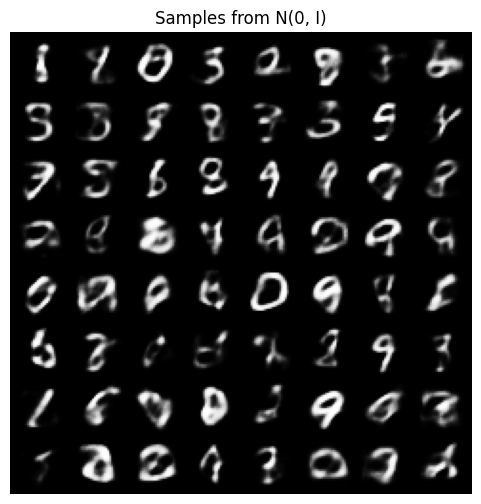

In [7]:
vae.eval()
with torch.no_grad():
    z = torch.randn(64, vae.latent_dim, device=device)
    samples = vae.decode(z)
show_batch(samples, title="Samples from N(0, I)")
